# HEST cell-type deconvolution — Figure 4D

Reproduces the annotated-HEST benchmark from Shulman et al., *Cell* 2026 — two
Visium breast-cancer slides (TENX13 / TENX39) with spot-level pathologist
cell-type annotations. Four predictors of cancer / stromal / TIL presence are
compared by AUC:

- **SpaCET (Measured GE)** — SpaCET on the measured Visium expression.
- **Path2Space (Inferred GE)** — the supervised 5-fold MLP (`deconv_fold_*`)
  applied to Path2Space-inferred expression. Predicted **live** in this notebook.
- **SpaCET (Inferred GE)** — SpaCET on Path2Space-inferred expression.
- **HoVer-Net (H&E)** — a direct H&E nuclear classifier.

AUC is computed per slide on spots non-NaN across all four methods, kept when
the slide has > 20 positive spots, and averaged over the two slides with a
1,000-sample bootstrap 95% CI.

## Setup

In [1]:
import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings("ignore")

## Path2Space (Inferred GE) — live MLP prediction

The five fold-models are averaged over the Path2Space-inferred expression of
the HEST spots (test-set mode). Spot ids are mapped from `NN_<slide>_<xy>` to
the `<slide>_<xy>` form used by the annotation table.

In [2]:
expr = pd.read_csv("../data/hest_expression.csv.gz", index_col=0)
print(f"{expr.shape[0]} HEST spots x {expr.shape[1]} genes")

CELL_TYPES = ["TILs", "Stromal", "Epithelial"]          # MLP output order
fold_preds = []
for i in range(5):
    model = joblib.load(f"../models/deconv_fold_{i}.joblib")
    feats = model.named_steps["scaler"].get_feature_names_out()
    fold_preds.append(model.predict(expr[feats]))
p2s = pd.DataFrame(np.mean(fold_preds, axis=0), index=expr.index, columns=CELL_TYPES)
p2s = p2s.rename(columns={"Epithelial": "Cancer"})       # match annotation naming
p2s.index = ["_".join(s.split("_")[1:]) for s in p2s.index]   # NN_FFPE_3x4 -> FFPE_3x4
print("Path2Space (Inferred GE) predictions:", p2s.shape)

6227 HEST spots x 1448 genes


Path2Space (Inferred GE) predictions: (6227, 3)


## The other three methods

`hest_method_predictions.csv` carries the per-spot scores and pathologist
labels for SpaCET (measured) and HoVer-Net. SpaCET-on-inferred is built from
the per-slide SpaCET outputs (35 fine cell types collapsed to three classes).

In [3]:
CELL_TYPE_MAP = {
    "Malignant": "Tumor", "CAF": "Stroma", "Endothelial": "Stroma",
    "Plasma": "Lymphocyte", "B cell": "Lymphocyte", "T CD4": "Lymphocyte",
    "T CD8": "Lymphocyte", "NK": "Lymphocyte", "cDC": "Stroma", "pDC": "Stroma",
    "Macrophage": "Stroma", "Mast": "Stroma", "Neutrophil": "Stroma",
    "B cell naive": "Lymphocyte", "B cell non-switched memory": "Lymphocyte",
    "B cell switched memory": "Lymphocyte", "B cell exhausted": "Lymphocyte",
    "T CD4 naive": "Lymphocyte", "Th1": "Lymphocyte", "Th2": "Lymphocyte",
    "Th17": "Lymphocyte", "Tfh": "Lymphocyte", "Treg": "Lymphocyte",
    "T CD8 naive": "Lymphocyte", "T CD8 central memory": "Lymphocyte",
    "T CD8 effector memory": "Lymphocyte", "T CD8 effector": "Lymphocyte",
    "T CD8 exhausted": "Lymphocyte", "cDC1 CLEC9A": "Stroma",
    "cDC2 CD1C": "Stroma", "cDC3 LAMP3": "Stroma", "Macrophage M1": "Stroma",
    "Macrophage M2": "Stroma", "Macrophage other": "Stroma",
}
RENAME = {"Lymphocyte": "TILs", "Stroma": "Stromal", "Tumor": "Cancer"}

# SpaCET on Path2Space-inferred expression, per slide
sp_inf = []
for slide, tag in [("TENX13", "block1"), ("TENX39", "FFPE")]:
    s = pd.read_csv(f"../data/hest_spacet_inferred_{slide}.csv", index_col=0)
    s = s.loc[s.index.isin(CELL_TYPE_MAP)]
    s.index = s.index.map(CELL_TYPE_MAP)
    s = s.groupby(level=0).sum().T.rename(columns=RENAME)
    s.index = tag + "_" + s.index.str.split("_").str[-1]
    sp_inf.append(s)
sp_inf = pd.concat(sp_inf)
print("SpaCET (Inferred GE) predictions:", sp_inf.shape)

df = pd.read_csv("../data/hest_method_predictions.csv")
print("methods in hest_method_predictions.csv:", sorted(df["method"].unique()))

SpaCET (Inferred GE) predictions: (6238, 3)
methods in hest_method_predictions.csv: ['HoVer-Net', 'SpaCET', 'p2s']


## Assemble the four methods

The `p2s` rows are overwritten with the live MLP prediction, and a
`p2s_spacet` block is added from the SpaCET-on-inferred fractions.

In [4]:
# overwrite p2s with the live MLP prediction
m = df["method"] == "p2s"
df.loc[m, "y_pred_proba"] = [p2s.loc[r["index"], r["cell_type"]]
                             if r["index"] in p2s.index else np.nan
                             for _, r in df[m].iterrows()]

# add p2s_spacet (SpaCET on inferred) from sp_inf
lab = df.loc[df["method"] == "SpaCET", ["cell_type", "index", "slide", "y_test"]].copy()
lab["method"] = "p2s_spacet"
lab["y_pred_proba"] = [sp_inf.loc[r["index"], r["cell_type"]]
                       if r["index"] in sp_inf.index else np.nan
                       for _, r in lab.iterrows()]
df = pd.concat([df, lab], ignore_index=True)
print("methods:", sorted(df["method"].unique()))

methods: ['HoVer-Net', 'SpaCET', 'p2s', 'p2s_spacet']


## AUC per slide with bootstrap CI

Each (slide, cell type) AUC is computed on spots non-NaN across all four
methods; the 95% CI is a 1,000-sample bootstrap. Results are averaged over the
two slides, keeping (slide, cell type) entries with > 20 positive spots.

In [5]:
def bootstrap_auc(y_true, y_pred, n_boot=1000, seed=42):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    aucs = []
    for _ in range(n_boot):
        idx = rng.choice(n, n, replace=True)
        yt, yp = y_true.iloc[idx], y_pred.iloc[idx]
        if len(np.unique(yt)) == 2:
            aucs.append(roc_auc_score(yt, yp))
    return np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)

CELL_ORDER = ["Cancer", "Stromal", "TILs"]
labels = df.loc[df["method"] == "SpaCET", ["cell_type", "index", "slide", "y_test"]]

# spots non-NaN across all four methods
common = {}
for sl in ["block1", "FFPE"]:
    common[sl] = {}
    for ct in CELL_ORDER:
        cs = set(labels.loc[(labels.slide == sl) & (labels.cell_type == ct)]
                 .dropna()["index"])
        for mth in df["method"].unique():
            dm = df.loc[(df.method == mth) & (df.slide == sl) & (df.cell_type == ct)]
            cs &= set(dm.dropna()["index"])
        common[sl][ct] = list(cs)

rows = []
for sl in ["block1", "FFPE"]:
    for mth in df["method"].unique():
        for ct in CELL_ORDER:
            d = df.loc[(df.method == mth) & (df.slide == sl) & (df.cell_type == ct)].set_index("index")
            cs = common[sl][ct]
            yt, yp = d.loc[cs, "y_test"], d.loc[cs, "y_pred_proba"]
            lo, hi = bootstrap_auc(yt, yp)
            rows.append({"method": mth, "cell_type": ct, "slide": sl,
                         "auc": roc_auc_score(yt, yp),
                         "ci_lower": lo, "ci_upper": hi, "n_pos": yt.sum()})
res = pd.DataFrame(rows)

agg = (res[res["n_pos"] > 20]
       .groupby(["method", "cell_type"])[["auc", "ci_lower", "ci_upper"]]
       .mean().reset_index())
NAME = {"SpaCET": "SpaCET (Measured GE)", "p2s": "Path2Space (Inferred GE)",
        "p2s_spacet": "SpaCET (Inferred GE)", "HoVer-Net": "HoVer-Net (H&E)"}
agg["method"] = agg["method"].map(NAME)
agg["yerr_lo"] = agg["auc"] - agg["ci_lower"]
agg["yerr_hi"] = agg["ci_upper"] - agg["auc"]
agg.round(3)

,method,cell_type,auc,ci_lower,ci_upper,yerr_lo,yerr_hi
0,HoVer-Net (H&E),Cancer,0.789,0.772,0.808,0.017,0.019
1,HoVer-Net (H&E),Stromal,0.713,0.691,0.734,0.022,0.021
2,HoVer-Net (H&E),TILs,0.865,0.837,0.893,0.028,0.028
3,SpaCET (Measured GE),Cancer,0.931,0.920,0.940,0.010,0.010
4,SpaCET (Measured GE),Stromal,0.937,0.927,0.946,0.010,0.009
5,SpaCET (Measured GE),TILs,0.823,0.790,0.855,0.032,0.033
6,Path2Space (Inferred GE),Cancer,0.893,0.880,0.906,0.013,0.013
7,Path2Space (Inferred GE),Stromal,0.849,0.835,0.864,0.015,0.015
8,Path2Space (Inferred GE),TILs,0.919,0.898,0.938,0.021,0.019
9,SpaCET (Inferred GE),Cancer,0.891,0.878,0.904,0.013,0.013


## Figure 4D — annotated-HEST AUC

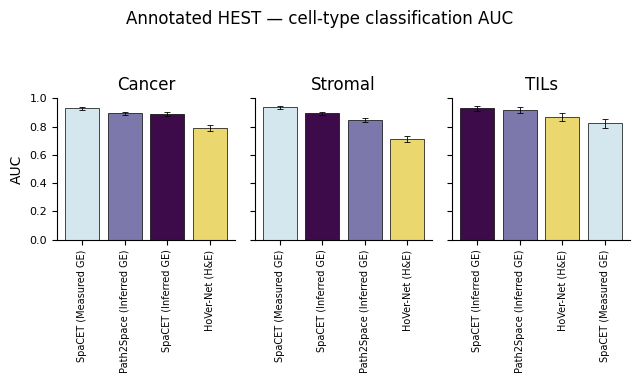

In [6]:
palette = {"SpaCET (Measured GE)": "#d1e9f2", "Path2Space (Inferred GE)": "#7570b3",
           "SpaCET (Inferred GE)": "#440154", "HoVer-Net (H&E)": "#ffe759"}

fig, axes = plt.subplots(1, 3, figsize=(6.5, 3.6), sharey=True)
for ax, ct in zip(axes, CELL_ORDER):
    d = agg[agg["cell_type"] == ct].sort_values("auc", ascending=False)
    sns.barplot(data=d, x="method", y="auc", hue="method", palette=palette,
                order=d["method"], hue_order=d["method"], dodge=False,
                edgecolor="black", linewidth=0.5, ax=ax)
    for patch, (_, r) in zip(ax.patches, d.iterrows()):
        ax.errorbar(patch.get_x() + patch.get_width() / 2, r["auc"],
                    yerr=[[r["yerr_lo"]], [r["yerr_hi"]]], fmt="none",
                    ecolor="black", elinewidth=0.6, capsize=2, capthick=0.6)
    ax.set(ylim=(0, 1.0), xlabel="", title=ct)
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    ax.tick_params(axis="y", labelsize=8)
    ax.set_ylabel("AUC" if ct == "Cancer" else "")
    ax.set_xticks(range(len(d)))
    ax.set_xticklabels(d["method"], rotation=90, fontsize=7)
    if ax.legend_: ax.legend_.remove()
sns.despine()
fig.suptitle("Annotated HEST — cell-type classification AUC", y=1.05)
fig.tight_layout()
plt.show()

## Summary

AUC by method and cell type, averaged over the two HEST slides.

In [7]:
tab = agg.pivot(index="method", columns="cell_type", values="auc")[CELL_ORDER]
print(tab.round(3))

cell_type                 Cancer  Stromal   TILs
method                                          
HoVer-Net (H&E)            0.789    0.713  0.865
Path2Space (Inferred GE)   0.893    0.849  0.919
SpaCET (Inferred GE)       0.891    0.894  0.931
SpaCET (Measured GE)       0.931    0.937  0.823
